# Phase 3 – File 1: Partial Derivatives & the Gradient

**The mathematics that lets a neural network *know* how to change its millions of weights.**

---

## 1. Why do we need *partial* derivatives?

So far we have dealt with **functions of a single variable**:

$$ f(x) = x^2 + 3x $$

The ordinary derivative $f'(x)$ tells us **how fast $f$ changes when we move $x$**.

In **deep learning** the **loss function** $L$ depends on **millions of parameters** (weights $w_1,w_2,…,w_n$ and biases $b_1,b_2,…$):

$$ L = L(w_1,w_2,…,w_n,b_1,b_2,…,b_m) $$

If we want to know *how to adjust only $w_1$* while keeping every other knob fixed, we must compute a **partial derivative**:

$$ \frac{\partial L}{\partial w_1} $$

The symbol $\partial$ (pronounced “partial del”) is a visual cue that **all other variables are treated as constants**.

---

## 2. The rule in words

> **Treat every variable except the one you are differentiating with respect to as a constant.**

Think of a multi‑knob machine. To see how turning knob #1 affects the output, you **freeze** all other knobs.

---

## 3. Example 1 – $f(x,y) = x^2 + y^3$

### 3.1 Differentiate with respect to $x$

1. **Freeze $y$** → $y^3$ becomes a constant (imagine $y=2$, then $y^3=8$).
2. The function looks like $f = x^2 + \text{constant}$.
3. Derivative of $x^2$ is $2x$.
4. Derivative of a constant is $0$.

$$ \boxed{\frac{\partial f}{\partial x} = 2x} $$

### 3.2 Differentiate with respect to $y$

1. **Freeze $x$** → $x^2$ is now a constant.
2. $f = \text{constant} + y^3$.
3. Derivative of $y^3$ is $3y^2$.

$$ \boxed{\frac{\partial f}{\partial y} = 3y^2} $$

---

## 4. Example 2 – $g(w_1,w_2) = 5 w_1^3 w_2^4$  (exactly the shape you see in a weight matrix)

### 4.1 $\frac{\partial g}{\partial w_1}$

- **Freeze $w_2$** → $5 w_2^4$ is a constant multiplier, call it $C = 5 w_2^4$.
- $g = C \cdot w_1^3$.
- **Constant‑multiple rule**: derivative of $C \cdot u$ is $C \cdot u'$.
- $u = w_1^3 \; \Rightarrow\; u' = 3 w_1^2$.
- Therefore $\frac{\partial g}{\partial w_1} = C \cdot 3 w_1^2 = 5 w_2^4 \cdot 3 w_1^2$.

$$ \boxed{\frac{\partial g}{\partial w_1} = 15 w_1^2 w_2^4} $$

### 4.2 $\frac{\partial g}{\partial w_2}$

- **Freeze $w_1$** → $5 w_1^3$ is the constant $D$.
- $g = D \cdot w_2^4$.
- Derivative of $w_2^4$ is $4 w_2^3$.

$$ \boxed{\frac{\partial g}{\partial w_2} = 20 w_1^3 w_2^3} $$

---

## 5. The Gradient – a vector of *all* partial derivatives

For a loss $L(w_1,w_2,…,w_n)$ the **gradient** is the row vector

$$ \nabla L = \Big[ \frac{\partial L}{\partial w_1}, \frac{\partial L}{\partial w_2}, \dots, \frac{\partial L}{\partial w_n} \Big] $$

### 5.1 Geometric meaning

- Imagine the **loss surface** as a 3‑D mountain where axes are $w_1$, $w_2$, height = $L$.
- At any point, the gradient vector **points toward the steepest uphill direction**.
- Therefore **$-\nabla L$ points downhill** – the direction we want to move to reduce error.

---

## 6. Code – compute partials with SymPy

Run the cell to see the symbolic results.

In [ ]:
import sympy as sp
from IPython.display import display, Math
sp.init_printing()

# ---- Example 1 ----
x, y = sp.symbols('x y')
f = x**2 + y**3
display(Math(r'f(x,y) = ' + sp.latex(f)))
display(Math(r'\frac{\partial f}{\partial x} = ' + sp.latex(sp.diff(f, x))))
display(Math(r'\frac{\partial f}{\partial y} = ' + sp.latex(sp.diff(f, y))))

# ---- Example 2 ----
w1, w2 = sp.symbols('w_1 w_2')
g = 5 * w1**3 * w2**4**4
display(Math(r'g(w_1,w_2) = ' + sp.latex(g)))
display(Math(r'\frac{\partial g}{\partial w_1} = ' + sp.latex(sp.diff(g, w1))))
display(Math(r'\frac{\partial g}{\partial w_2} = ' + sp.latex(sp.diff(g, w2))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 7. Practice Problem – *You* compute it!

$$ h(a,b) = a\ln(b) + \frac{1}{a^2 + b^2} $$

Find $\frac{\partial h}{\partial a}$ and $\frac{\partial h}{\partial b}$ **by hand first**, then run the cell to check.

In [ ]:
a, b = sp.symbols('a b')
h = a * sp.ln(b) + 1 / (a**2 + b**2)

display(Math(r'h(a,b) = ' + sp.latex(h)))
display(Math(r'\frac{\partial h}{\partial a} = ' + sp.latex(sp.diff(h, a))))
display(Math(r'\frac{\partial h}{\partial b} = ' + sp.latex(sp.diff(h, b))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 8. Visualising the gradient (2‑D loss surface)

The code below plots $L(w_1,w_2) = w_1^2 + w_2^2 + 2w_1w_2$ and draws the gradient vector at a few points.

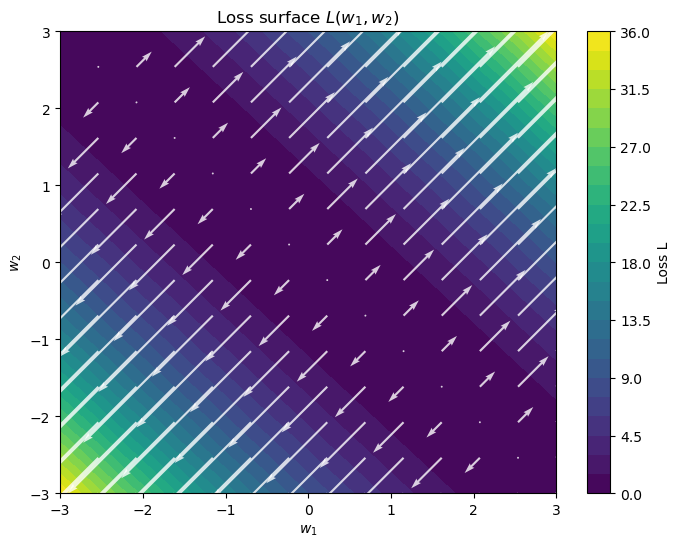

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

w1 = np.linspace(-3, 3, 40)
w2 = np.linspace(-3, 3, 40)
W1, W2 = np.meshgrid(w1, w2)
L = W1**2 + W2**2 + 2*W1*W2

plt.figure(figsize=(8,6))
cp = plt.contourf(W1, W2, L, levels=30, cmap='viridis')
plt.colorbar(cp, label='Loss L')
plt.title('Loss surface $L(w_1,w_2)$')
plt.xlabel('$w_1$')
plt.ylabel('$w_2$')

# Gradient field
grad_w1 = 2*W1 + 2*W2
grad_w2 = 2*W2 + 2*W1
plt.quiver(W1[::3,::3], W2[::3,::3], grad_w1[::3,::3], grad_w2[::3,::3],
           scale=30, color='white', alpha=0.8)
plt.show()

## 9. TL;DR Summary

- **Partial derivative** = ordinary derivative while treating every other variable as a constant.
- **Gradient** = vector of all partials → points to steepest ascent.
- **AI uses $-\nabla L$** to move weights *down* the loss surface.

---

**You now understand the mathematical foundation of *learning*.**  
Next file: **Gradient Descent** – how we *actually* take steps.